In [ ]:
!pip install torch
!pip install pytorch-tabular[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.4/891.4 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successful

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import torch
from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from pytorch_tabular.models.ft_transformer import FTTransformerConfig

import matplotlib.pyplot as plt
import shap

ModuleNotFoundError: No module named 'pytorch_tabular'

In [ ]:
# Carga de los datos
df = pd.read_csv("df_limpios_con_vd.csv")

print(df.shape)
print(df['is_good_offer'].value_counts(normalize=True))
df.head()

(17461, 39)
is_good_offer
0    0.657007
1    0.342993
Name: proportion, dtype: float64


,address,bathrooms,detailedType.subTypology,detailedType.typology,district,exterior,floor,has360,has3DTour,hasLift,...,rooms,showAddress,size,status,suggestedTexts.subtitle,suggestedTexts.title,topPlus,geo_zone,cluster_id,is_good_offer
0,calle de las Aguas,1,penthouse,flat,Centro,1,4,0,1,1,...,2,0,106.0,good,"Palacio, Madrid",Ático en calle de las Aguas,1,24.0,48,0
1,calle de Esparteros,1,flat,flat,Centro,1,3,0,1,1,...,5,0,140.0,good,"Sol, Madrid",Piso en calle de Esparteros,1,24.0,7,0
2,calle de las Aguas,1,flat,flat,Centro,1,4,0,1,1,...,2,0,106.0,good,"Palacio, Madrid",Piso en calle de las Aguas,1,24.0,0,0
3,paseo de los Parques,3,flat,flat,Encinar de los Reyes,1,0,0,1,1,...,3,0,166.0,good,"Encinar de los Reyes, La Moraleja",Piso en paseo de los Parques,1,18.0,5,1
4,avenida de Luis García Cereceda,4,flat,flat,Zona Prado de Somosaguas - La Finca,1,0,0,1,1,...,4,0,188.0,good,"La Finca, Pozuelo de Alarcón",Piso en avenida de Luis García Cereceda,1,16.0,27,0


In [ ]:
# Target
y = df['is_good_offer']

# Opcional: filtrar variables categóricas con demasiados valores únicos si se nos ha olvidado
filter_high_cardinality = True  # Cambiar a False si no quieres filtrar

if filter_high_cardinality:
    # Columnas categóricas
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    max_unique = 50
    cols_to_keep = [col for col in categorical_cols if df[col].nunique() <= max_unique]
else:
    cols_to_keep = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Columnas numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('price') if 'price' in numeric_cols else None
numeric_cols.remove('is_good_offer') if 'is_good_offer' in numeric_cols else None

# Columnas finales a usar
X = df[numeric_cols + cols_to_keep]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de test: {X_test.shape}")
print(f"Número de columnas categóricas usadas: {len(cols_to_keep)}")


Tamaño de entrenamiento: (13968, 31)
Tamaño de test: (3493, 31)
Número de columnas categóricas usadas: 6


### ¿Por qué eliminamos la variable `price`?

La variable `price` **no se incluye como feature** porque la etiqueta objetivo `is_good_offer` se ha generado a partir de este valor. Incluirla supondría **data leakage**, ya que el modelo aprendería de forma trivial que un precio bajo implica “buena oferta”, sin captar patrones reales en las características del inmueble.  

Además:  
- **Riesgo de sobreajuste:** El modelo memorizaría el precio en lugar de generalizar a partir de atributos estructurales y de ubicación.  
- **Escenario realista:** El objetivo es que, dado un inmueble con sus características (tipo, tamaño, ubicación, etc.), el modelo prediga si un precio propuesto es una buena oferta en su contexto, sin usar el precio como entrada directa.  


In [ ]:
non_numeric_cols = [col for col in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[col])]
print("Columnas con valores no numéricos:", non_numeric_cols)

# Opcional: ver los valores únicos de cada columna no numérica
for col in non_numeric_cols:
    print(f"\nValores únicos en {col}:")
    print(X_train[col].unique())

Columnas con valores no numéricos: ['detailedType.subTypology', 'detailedType.typology', 'floor', 'numPhotos', 'propertyType', 'status']

Valores únicos en detailedType.subTypology:
['flat' 'independantHouse' 'terracedHouse' 'penthouse' 'duplex'
 'semidetachedHouse' 'studio' 'chalet' 'countryHouse' 'casale'
 'casaDePueblo' 'palacio' 'masia' 'caseron' 'cortijo']

Valores únicos en detailedType.typology:
['flat' 'chalet' 'countryHouse']

Valores únicos en floor:
['3' 'house' '1' '4' '6' '2' '7' '5' '0' '8' '10' '9' '14' '-1' '11' '15+'
 '13' '12']

Valores únicos en numPhotos:
['30-50' '5-10' '20-30' '10-20' '50-60' '0-5' '+60']

Valores únicos en propertyType:
['flat' 'chalet' 'penthouse' 'duplex' 'studio' 'countryHouse']

Valores únicos en status:
['good' 'newdevelopment' 'renew']


In [ ]:
# Categóricas
# Columnas a codificar
onehot_cols = ['status', 'propertyType', 'detailedType.typology', 'detailedType.subTypology']
ordinal_cols = ['floor', 'numPhotos']

# Orden Ordinal: floor y numPhotos
floor_categories = [
    "-1", "house", "0", "1", "2", "3", "4", "5", "6", "7",
    "8", "9", "10", "11", "12", "13", "14", "15+"
]
numPhotos_categories = [
    '0-5', '5-10', '10-20', '20-30', '30-50', '50-60', '+60'
]

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore')
X_onehot = pd.DataFrame(ohe.fit_transform(X_train[onehot_cols]),
                        columns=ohe.get_feature_names_out(onehot_cols),
                        index=X_train.index)


# Ordinal Encoding
ord_enc = OrdinalEncoder(categories=[floor_categories, numPhotos_categories], dtype=int)
X_ordinal = pd.DataFrame(ord_enc.fit_transform(X_train[ordinal_cols]),
                         columns=ordinal_cols,
                         index=X_train.index)

# Combinar todo con el resto de columnas numéricas
X_train_encoded = pd.concat([X_train.drop(columns=onehot_cols+ordinal_cols),
                             X_onehot, X_ordinal], axis=1)

# Hacer lo mismo para X_test
X_onehot_test = pd.DataFrame(ohe.transform(X_test[onehot_cols]),
                             columns=ohe.get_feature_names_out(onehot_cols),
                             index=X_test.index)

X_ordinal_test = pd.DataFrame(ord_enc.transform(X_test[ordinal_cols]),
                              columns=ordinal_cols,
                              index=X_test.index)

X_test_encoded = pd.concat([X_test.drop(columns=onehot_cols+ordinal_cols),
                            X_onehot_test, X_ordinal_test], axis=1)


In [ ]:
# Numéricas
# Column Numérica
numeric_cols = X_train.drop(columns=onehot_cols + ordinal_cols).columns

# Definir Scaler
scaler = StandardScaler()

# Fit-transform en train
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

# Transform en test
X_num_scaled_test = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

In [ ]:
# Train
X_train = pd.concat([X_num_scaled, X_onehot, X_ordinal], axis=1)
y_train = y_train
# Test
X_test = pd.concat([X_num_scaled_test, X_onehot_test, X_ordinal_test], axis=1)
y_test = y_test

In [ ]:
print(X_train.shape)
print(X_test.shape)

(13968, 50)
(3493, 50)


##### Modelo secuencial ANN Binaria

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Class Weights: {0: 0.7610330173259235, 1: 1.4577332498434565}
Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6179 - loss: 0.7049 - val_accuracy: 0.7928 - val_loss: 0.4684
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7409 - loss: 0.5140 - val_accuracy: 0.7924 - val_loss: 0.4330
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7613 - loss: 0.4603 - val_accuracy: 0.8150 - val_loss: 0.3915
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7818 - loss: 0.4315 - val_accuracy: 0.8289 - val_loss: 0.3765
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8033 - loss: 0.3994 - val_accuracy: 0.8336 - val_loss: 0.3634
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8138 - loss: 0.4036 - val_accuracy: 0.8368 - val_loss: 0.3482
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8131 - loss: 0.3872 - val_accuracy: 0.8350 - val_loss: 0.3537
Epoch 8/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 

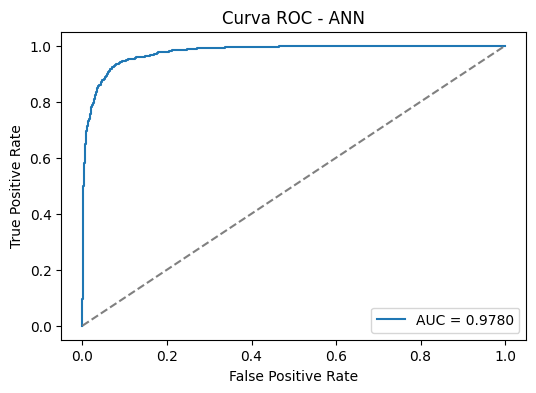

In [ ]:
# Dimensiones de entrada
input_dim = X_train.shape[1]

# Definición del modelo NN
model = Sequential([
    Dense(256, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Categórica: softmax, numérica: lineal
])

# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Calcular class weights para balancear las clases
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# Entrenamiento con EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------- Evaluación ----------------------
print("\n--- Evaluación ANN con Class Weights ---")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Matriz de confusión y reporte
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Calcular y mostrar AUC
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC: {auc:.4f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - ANN")
plt.legend()
plt.show()

Uso de class_weight en el modelo:
Dado que la variable objetivo presenta un desbalance (alrededor de un 65% de clase 0 y un 35% de clase 1), sin ajustar el modelo tendería a predecir mayoritariamente la clase mayoritaria, reduciendo el recall en la minoritaria. Para compensar esto, se aplicó la técnica de class_weight en el entrenamiento, asignando mayor peso a los errores en la clase minoritaria. Esto obliga a la red a prestar más atención a las “buenas ofertas” (clase 1), logrando una mejora sustancial en recall y F1-score, sin comprometer en exceso la precisión global.

##### Ft-transform (Vemos cual da mejor resultado entre los dos para usarlo despues)

Probando con la version 2

- Modelo ANN profunda con regularizacion
- Modelo con Embeddings
- Modelo Wide & Deep que combina memorización y generalización.

In [2]:
# --- Importaciones Generales ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocesamiento ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error


# --- Deep Learning (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Embedding, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# --- Instalación de Keras Tuner ---
#!pip install -q keras-tuner

import keras_tuner as kt


In [3]:
#Carpeta de ficheros_csv del drive
!gdown --folder -q https://drive.google.com/drive/folders/1GcfvHOr_N3NyKCmp6w1dX6HJ2JRfO1mD?usp=drive_link

In [4]:

# --- Carga del Dataset ---
df_modelado = pd.read_csv('/content/Ficheros CSV/df_limpios_con_vd V.2.csv')

df_modelado.shape

/tmp/ipython-input-150092601.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_modelado = pd.read_csv('/content/Ficheros CSV/df_limpios_con_vd V.2.csv')


(17456, 39)

In [5]:
df_modelado['floor'].value_counts(dropna = False)

,count
floor,
0.0,6738
1.0,2571
2.0,2104
3.0,1811
4.0,1297
5.0,752
6.0,466
0.0,465
7.0,280


In [6]:
# Copiar para trabajar sobre una versión limpia y evitar warnings
df_modelado_clean = df_modelado.copy()

# 1. Reemplazar valores de texto conocidos. '15+' se convierte en 15.
df_modelado_clean['floor'] = df_modelado_clean['floor'].replace('15+', '15')

# 2. Forzar la conversión a numérico. 'errors=coerce' convierte lo que no sea un número en NaN.
df_modelado_clean['floor'] = pd.to_numeric(df_modelado_clean['floor'], errors='coerce')

df_modelado_clean['floor'] = df_modelado_clean['floor'].clip(upper=15)

# 5. Convertir la columna a un tipo de dato entero para finalizar.
df_modelado_clean['floor'] = df_modelado_clean['floor'].astype(int)

df_modelado = df_modelado_clean.copy()

In [7]:
df_modelado['floor'].value_counts(dropna = False)

,count
floor,
0,7203
1,2710
2,2243
3,1939
4,1393
5,797
6,495
7,297
8,145


### Preparación de Datos

Se definen las variables predictoras (X) y la objetivo (y). Se eliminan las columnas que podrían causar fuga de datos (como las relacionadas con el precio) o que son redundantes. Finalmente, se dividen los datos en conjuntos de entrenamiento y prueba.

In [8]:
#Separar la variable objetivo (y) y las predictoras (X)
X = df_modelado.drop('deal_score', axis=1)
y = df_modelado['deal_score']

# Columnas a excluir
cols_to_exclude = [
    'price', 'priceByArea', 'price_per_room',
    'priceInfo.price.priceDropInfo.priceDropPercentage',
    'priceInfo.price.priceDropInfo.priceDropValue',
    'latitude', 'longitude'
]
X = X.drop(columns=cols_to_exclude)

# Identificar columnas numéricas y categóricas restantes
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 'zona_cluster' pasar a categorica
if 'zona_cluster' in numeric_features:
    numeric_features.remove('zona_cluster')
    categorical_features.append('zona_cluster')

print(f"Se usarán {len(numeric_features)} features numéricas y {len(categorical_features)} categóricas.")

# 4. Dividir los datos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDatos divididos en conjuntos de entrenamiento y prueba:")
print(f" - Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f" - Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Se usarán 22 features numéricas y 9 categóricas.

Datos divididos en conjuntos de entrenamiento y prueba:
 - Tamaño del conjunto de entrenamiento: 13964 muestras
 - Tamaño del conjunto de prueba: 3492 muestras


### Preprocesamiento de Datos
Antes de que los datos puedan ser utilizados por una red neuronal, deben ser transformados a un formato puramente numérico. Este proceso se realiza mediante un ColumnTransformer:

- **StandardScaler**: Se aplica a las variables numéricas. Estandariza cada característica para que tenga una media de 0 y una desviación estándar de 1. Esto es crucial para que el modelo de Deep Learning converja de manera eficiente.

- **OneHotEncoder**: Se aplica a las variables categóricas. Convierte cada categoría (ej. 'Centro', 'Piso') en una nueva columna binaria (0 o 1). Esto permite al modelo entender las categorías sin asumir un orden numérico entre ellas.

Este pipeline de preprocesamiento se ajusta únicamente con los datos de entrenamiento para evitar la fuga de datos (data leakage) y luego se aplica tanto al conjunto de entrenamiento como al de prueba.

In [9]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Crear el pipeline de preprocesamiento
preprocessor_ohe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas no especificadas (si las hubiera)
)

# Aplicar el preprocesamiento
X_train_ohe = preprocessor_ohe.fit_transform(X_train)
X_test_ohe = preprocessor_ohe.transform(X_test)

print("Preprocesamiento completado.")
print(f" - Dimensiones del conjunto de entrenamiento procesado: {X_train_ohe.shape}")
print(f" - Dimensiones del conjunto de prueba procesado: {X_test_ohe.shape}")

Preprocesamiento completado.
 - Dimensiones del conjunto de entrenamiento procesado: (13964, 374)
 - Dimensiones del conjunto de prueba procesado: (3492, 374)


### Modelo 1: ANN Profunda con Regularización
Este modelo sirve como una base sólida para nuestro análisis. Es una red neuronal con múltiples capas densas que utiliza dos técnicas clave de regularización para mejorar su rendimiento y evitar el sobreajuste:

- **Batch Normalization:** Estabiliza y acelera el proceso de aprendizaje al normalizar las salidas de cada capa.

- **Dropout**: "Apaga" neuronas al azar durante cada ciclo de entrenamiento, forzando al modelo a aprender rutas de decisión más robustas y a no depender de unas pocas neuronas.

La arquitectura está diseñada para capturar patrones complejos en los datos, y el EarlyStopping se utiliza para detener el entrenamiento automáticamente cuando el modelo deja de mejorar, asegurando que nos quedemos con la mejor versión posible.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.8630 - val_loss: 0.2873
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4533 - val_loss: 0.2584
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3234 - val_loss: 0.2425
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2802 - val_loss: 0.2367
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2552 - val_loss: 0.2291
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2447 - val_loss: 0.2249
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2330 - val_loss: 0.2138
Epoch 8/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2255 - val_loss: 0.2092
Epoch 9/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2217 - val_loss: 0.2029
Epoch 10/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2119 - val_loss: 0.2008
Epoch 11/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2142 - val_loss: 0.1988
Epoch 12/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/st

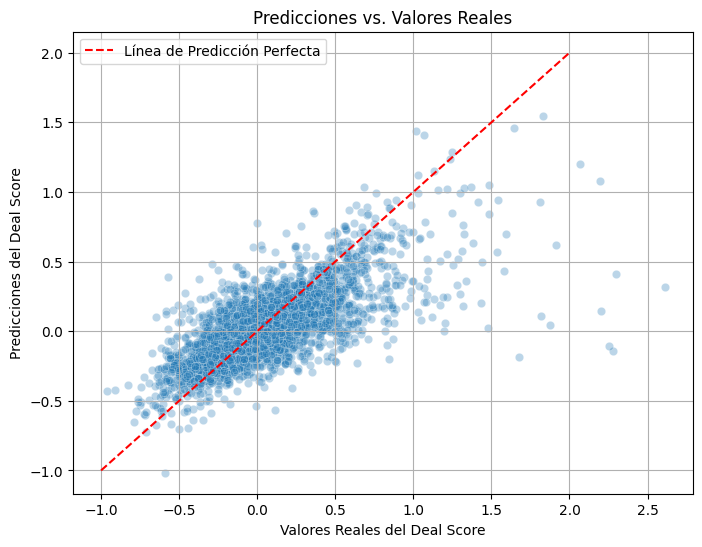

In [10]:
# Dimensiones de entrada (usando los datos ya preprocesados)
input_dim = X_train_ohe.shape[1]

# Definición del modelo NN
model_adapted = Sequential([
    Dense(256, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1)
])

model_adapted.compile(
    optimizer='adam',
    loss='mean_absolute_error'
)

# Entrenamiento con EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_adapted.fit(
    X_train_ohe, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------- Evaluación para REGRESIÓN ----------------------
print("\n--- Evaluación del Modelo de Regresión ---")
# Predecir los valores del 'deal_score' en el conjunto de prueba
y_pred = model_adapted.predict(X_test_ohe)

# Calcular el Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae:.4f}")

# Gráfico de Predicciones vs. Valores Reales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred.flatten(), alpha=0.3)
plt.plot([-1, 2], [-1, 2], linestyle='--', color='red', label='Línea de Predicción Perfecta')
plt.title('Predicciones vs. Valores Reales')
plt.xlabel('Valores Reales del Deal Score')
plt.ylabel('Predicciones del Deal Score')
plt.legend()
plt.grid(True)
plt.show()

**Análisis de Resultados: Modelo 1 - ANN Profunda**

El modelo establece una base de rendimiento (baseline) sólida y prometedora.

Con un Error Absoluto Medio (MAE) de 0.1813 en el conjunto de prueba, el modelo predice el deal_score con una desviación promedio del 18.13%. Este es un resultado inicial robusto que confirma la viabilidad del enfoque.

El gráfico de Predicciones vs. Valores Reales valida el aprendizaje del modelo, mostrando una fuerte correlación positiva: las predicciones siguen la tendencia de los valores reales. Sin embargo, la dispersión de los puntos alrededor de la línea de predicción perfecta indica que el modelo tiene margen de mejora, especialmente en la predicción de valores extremos (ofertas y sobreprecios muy pronunciados).

En conclusión, el modelo es funcional y nos proporciona un benchmark claro que los siguientes modelos más avanzados intentarán superar.

In [ ]:


# --- 1. Definir la función que construye el modelo (espacio de búsqueda) ---
def build_model(hp):
    # 'hp' es un objeto que nos permite definir los hiperparámetros a probar

    model = Sequential()

    # Capa de entrada
    model.add(Dense(
        # Probar con un número de neuronas entre 128 y 512, en pasos de 64
        units=hp.Int('units_input', min_value=128, max_value=512, step=64),
        activation='relu',
        input_shape=(X_train_ohe.shape[1],)
    ))

    # Añadir capas ocultas de forma condicional
    for i in range(hp.Int('num_layers', 1, 3)): # Probar entre 1 y 3 capas ocultas
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        model.add(BatchNormalization())
        model.add(Dropout(
            # Probar con una tasa de dropout entre 0.2 y 0.5
            rate=hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)
        ))

    # Capa de salida
    model.add(Dense(1))

    # Compilar el modelo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            # Probar con diferentes tasas de aprendizaje
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='mean_absolute_error'
    )
    return model

# --- 2. Configurar el Sintonizador (Tuner) ---
# Usaremos Hyperband, un algoritmo eficiente para la búsqueda
tuner = kt.Hyperband(
    build_model,
    objective='val_loss', # El objetivo es minimizar el error en la validación
    max_epochs=50,
    factor=3,
    directory='keras_tuner_dir', # Directorio para guardar los resultados
    project_name='idealista_regression'
)

# Definir un callback de EarlyStopping para la búsqueda
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- 3. Ejecutar la Búsqueda de Hiperparámetros ---
# El tuner probará diferentes combinaciones usando el conjunto de entrenamiento
tuner.search(
    X_train_ohe, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- 4. Obtener y Entrenar el Mejor Modelo ---
# Recuperar los mejores hiperparámetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nMejores hiperparámetros encontrados:\n - Unidades entrada: {best_hps.get('units_input')}\n - Nº Capas: {best_hps.get('num_layers')}\n - Tasa de Aprendizaje: {best_hps.get('learning_rate')}")

# Construir el modelo final con esos hiperparámetros
best_model = tuner.hypermodel.build(best_hps)

# Re-entrenar el mejor modelo con todos los datos de entrenamiento
history_best = best_model.fit(
    X_train_ohe, y_train,
    epochs=100, # Entrenar por más tiempo
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# --- 5. Evaluación Final ---
print("\n--- Evaluación del Mejor Modelo Encontrado por Keras Tuner ---")
mae_best_ann = best_model.evaluate(X_test_ohe, y_test, verbose=0)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae_best_ann:.4f}")

Trial 90 Complete [00h 01m 44s]
val_loss: 0.18337838351726532

Best val_loss So Far: 0.1829712837934494
Total elapsed time: 00h 31m 13s

Mejores hiperparámetros encontrados:
 - Unidades entrada: 448
 - Nº Capas: 2
 - Tasa de Aprendizaje: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Evaluación del Mejor Modelo Encontrado por Keras Tuner ---
Error Absoluto Medio (MAE) en el conjunto de prueba: 0.1954


### Modelo 2: Red Neuronal con Embeddings

Este modelo representa un salto cualitativo respecto al anterior. En lugar de utilizar One-Hot Encoding, que crea cientos de columnas dispersas para las variables categóricas, se emplea una técnica más inteligente: los embeddings.

Un embedding es una representación vectorial densa que el modelo aprende para cada categoría. Esto tiene dos ventajas principales:

- **Captura de Relaciones:** El modelo puede aprender que ciertas zona_cluster son conceptualmente similares entre sí, o que los "pisos" y los "apartamentos" tienen una relación más estrecha que con los "chalets". Esto es algo que el One-Hot Encoding no puede hacer.

- **Eficiencia Dimensional:** En lugar de necesitar 50 columnas para los 50 clusters, el modelo puede aprender una representación en, por ejemplo, 10 dimensiones, haciendo el proceso más eficiente.

Esta arquitectura requiere una preparación de datos ligeramente diferente (usando LabelEncoder) y se construye con la API Funcional de Keras para manejar las múltiples entradas (una por cada variable categórica y una para todas las numéricas).

#### Simple

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.2657 - val_loss: 0.2158
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2108 - val_loss: 0.2056
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1926 - val_loss: 0.1964
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1823 - val_loss: 0.1983
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1761 - val_loss: 0.1922
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1699 - val_loss: 0.1882
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1632 - val_loss: 0.1862
Epoch 8/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1590 - val_loss: 0.1860
Epoch 9/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1575 - val_loss: 0.1903
Epoch 10/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1529 - val_loss: 0.1875
Epoch 11/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1473 - val_loss: 0.1857
Epoch 12/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

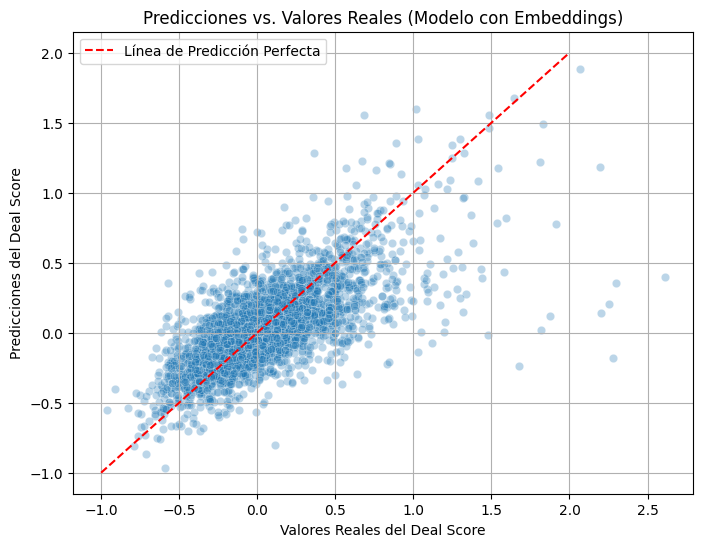

In [15]:
# --- 1. Preparación de datos específica para Embeddings ---
# Es necesario convertir las categorías a números enteros (0, 1, 2...)
X_train_emb = X_train.copy()
X_test_emb = X_test.copy()
embeddings_info = {}

for col in categorical_features:
    le = LabelEncoder()
    X_train_emb[col] = le.fit_transform(X_train_emb[col].astype(str))
    # Manejar posibles categorías en test que no estaban en train
    X_test_emb[col] = X_test_emb[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    num_categories = len(le.classes_)
    # Definir el tamaño del vector de embedding
    embedding_size = min(50, (num_categories + 1) // 2)
    embeddings_info[col] = (num_categories, embedding_size)

# Escalar las variables numéricas por separado
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_emb[numeric_features])
X_test_num_scaled = scaler.transform(X_test_emb[numeric_features])


# --- 2. Diseño del Modelo con la API Funcional ---
inputs = []
embedding_layers = []

# Crear una entrada y una capa de embedding para cada feature categórica
for col in categorical_features:
    num_categories, embedding_size = embeddings_info[col]
    input_cat = Input(shape=(1,), name=f'input_{col}')
    embedding = Embedding(input_dim=num_categories, output_dim=embedding_size, name=f'embedding_{col}')(input_cat)
    embedding = Flatten()(embedding)
    inputs.append(input_cat)
    embedding_layers.append(embedding)

# Crear una única entrada para todas las features numéricas
input_num = Input(shape=(len(numeric_features),), name='input_numeric')
inputs.append(input_num)

# Unir todas las capas (numéricas + embeddings)
concatenated = Concatenate()(embedding_layers + [input_num])

# Añadir las capas densas para la predicción
dense1 = Dense(256, activation='relu')(concatenated)
dense2 = Dense(128, activation='relu')(dense1)
output = Dense(1, name='output')(dense2)

# --- 3. Creación y Compilación del Modelo ---
model_emb = Model(inputs=inputs, outputs=output)
model_emb.compile(optimizer='adam', loss='mean_absolute_error')

# --- 4. Preparación de la lista de inputs para el entrenamiento ---
X_train_inputs = [X_train_emb[col].values for col in categorical_features] + [X_train_num_scaled]
X_test_inputs = [X_test_emb[col].values for col in categorical_features] + [X_test_num_scaled]

# --- 5. Entrenamiento ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_emb = model_emb.fit(
    X_train_inputs, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# --- 6. Evaluación ---
print("\n--- Evaluación del Modelo con Embeddings ---")
y_pred_emb = model_emb.predict(X_test_inputs)
mae_emb = mean_absolute_error(y_test, y_pred_emb)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae_emb:.4f}")

# --- Gráfico de Predicciones vs. Valores Reales para el Modelo con Embeddings ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.values, y=y_pred_emb.flatten(), alpha=0.3)
plt.plot([-1, 2], [-1, 2], linestyle='--', color='red', label='Línea de Predicción Perfecta')
plt.title('Predicciones vs. Valores Reales (Modelo con Embeddings)')
plt.xlabel('Valores Reales del Deal Score')
plt.ylabel('Predicciones del Deal Score')
plt.legend()
plt.grid(True)
plt.show()

#### Análisis de Resultados: Modelo 2 - Red Neuronal con Embeddings
Este modelo avanzado, que aprende las relaciones entre las categorías, ha demostrado ser altamente competitivo, obteniendo un rendimiento muy similar al del primer modelo ANN.

- **Rendimiento Numérico (MAE):** Con un Error Absoluto Medio (MAE) de 0.1852 en el conjunto de prueba, el modelo se equivoca, en promedio, un 18.52% al predecir el deal_score. Este resultado es excelente y confirma que la técnica de Embeddings es una alternativa muy potente y viable al One-Hot Encoding.

- **Análisis Gráfico (Predicciones vs. Reales):** El gráfico valida el buen rendimiento del modelo:

  Se observa una fuerte correlación positiva que sigue de cerca la línea roja de predicción perfecta. Esto indica que el modelo ha aprendido correctamente la relación fundamental entre las características de un inmueble y su valor relativo.

  La dispersión de los puntos alrededor de la línea es la representación visual del MAE. Al igual que en el primer modelo, vemos que el error es mayor en los extremos, lo que significa que al modelo le cuesta más predecir con precisión las ofertas y sobreprecios más extremos.

**Conclusión**
Ha logrado un rendimiento a la par con la arquitectura ANN profunda, demostrando que es una forma muy eficaz de tratar las variables categóricas.

#### Busqueda hiperparámetros

In [16]:
# --- 1. Definir la función que construye el modelo con Embeddings ---
def build_embedding_model(hp):
    inputs, embedding_layers = [], []

    # Crear entradas y embeddings para cada feature categórica
    for col in categorical_features:
        num_categories, _ = embeddings_info[col]

        # Hiperparámetro: Tamaño del embedding
        embedding_size = hp.Int(f'embedding_size_{col}', min_value=8, max_value=64, step=8)

        input_cat = Input(shape=(1,), name=f'input_{col}')
        embedding = Embedding(input_dim=num_categories, output_dim=embedding_size, name=f'embedding_{col}')(input_cat)
        embedding = Flatten()(embedding)
        inputs.append(input_cat)
        embedding_layers.append(embedding)

    input_num = Input(shape=(len(numeric_features),), name='input_numeric')
    inputs.append(input_num)
    concatenated = Concatenate()(embedding_layers + [input_num])

    # Hiperparámetro: Número de neuronas en la primera capa densa
    dense_units = hp.Int('dense_units', min_value=128, max_value=512, step=64)
    dense1 = Dense(dense_units, activation='relu')(concatenated)
    dense2 = Dense(dense_units // 2, activation='relu')(dense1) # La segunda capa es la mitad de la primera
    output = Dense(1, name='output')(dense2)

    model = Model(inputs=inputs, outputs=output)

    # Hiperparámetro: Tasa de aprendizaje
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mean_absolute_error')

    return model

# --- 2. Configurar y Ejecutar el Sintonizador ---
tuner_emb = kt.Hyperband(
    build_embedding_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    directory='keras_tuner_dir',
    project_name='idealista_embeddings'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# La búsqueda usa la lista de inputs que ya preparamos
tuner_emb.search(
    X_train_inputs, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- 3. Obtener, Entrenar y Evaluar el Mejor Modelo ---
best_hps_emb = tuner_emb.get_best_hyperparameters(num_trials=1)[0]
best_model_emb = tuner_emb.hypermodel.build(best_hps_emb)

history_best_emb = best_model_emb.fit(
    X_train_inputs, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print("\n--- Evaluación del Mejor Modelo con Embeddings Encontrado ---")
mae_best_emb = best_model_emb.evaluate(X_test_inputs, y_test, verbose=0)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae_best_emb:.4f}")

Trial 90 Complete [00h 00m 35s]
val_loss: 0.1890009194612503

Best val_loss So Far: 0.18035516142845154
Total elapsed time: 00h 26m 33s

--- Evaluación del Mejor Modelo con Embeddings Encontrado ---
Error Absoluto Medio (MAE) en el conjunto de prueba: 0.1844


### Modelo 3: Red Neuronal "Wide & Deep"
Esta arquitectura híbrida es una de las más potentes para datos tabulares, ya que combina lo mejor de dos mundos:

- La parte "Deep": Es una red neuronal profunda estándar. Su función es generalizar y encontrar patrones complejos y sutiles en el conjunto de todas las características.

- La parte "Wide": Actúa como un modelo lineal simple. Su función es memorizar reglas directas e importantes que correlacionan directamente ciertas características de entrada con la salida.

Al combinar ambas rutas, el modelo final puede realizar predicciones que son a la vez generalistas y específicas, a menudo logrando un rendimiento superior al de una red puramente profunda. Para este modelo, reutilizamos los datos ya procesados con One-Hot Encoding.

Epoch 1/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2529 - val_loss: 0.2112
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2012 - val_loss: 0.2013
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1824 - val_loss: 0.1962
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1743 - val_loss: 0.1933
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1625 - val_loss: 0.1924
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1586 - val_loss: 0.1872
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1516 - val_loss: 0.1861
Epoch 8/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1456 - val_loss: 0.1901
Epoch 9/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1424 - val_loss: 0.1847
Epoch 10/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1408 - val_loss: 0.1862
Epoch 11/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1365 - val_loss: 0.1851
Epoch 12/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

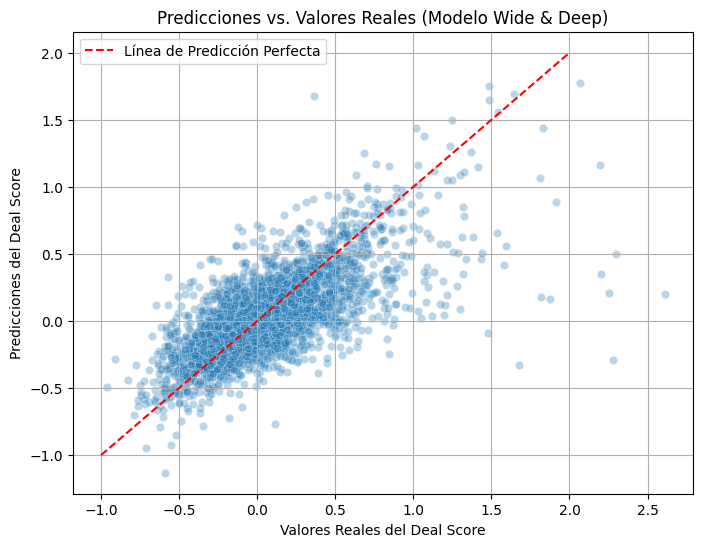

In [17]:
# Reutilizamos los datos con One-Hot Encoding (X_train_ohe, X_test_ohe)
input_layer = Input(shape=(X_train_ohe.shape[1],), name='input_main')

# --- Rama "Deep" ---
# Esta parte es una red neuronal profunda que aprende patrones complejos
deep_path = Dense(128, activation='relu', name='deep_1')(input_layer)
deep_path = Dense(64, activation='relu', name='deep_2')(deep_path)

# --- Rama "Wide" ---
# Esta parte es una "autopista" directa a la capa de combinación.
# Ayuda al modelo a memorizar reglas sencillas.
wide_path = Dense(32, activation='relu', name='wide_1')(input_layer)

# --- Combinación y Salida ---
# Se concatenan las salidas de ambas ramas
combined = Concatenate(name='concatenate')([wide_path, deep_path])
# La capa de salida final aprende de la información combinada
output_layer = Dense(1, name='output')(combined)


# --- 2. Creación y Compilación del Modelo ---
model_wide_deep = Model(inputs=input_layer, outputs=output_layer)
model_wide_deep.compile(optimizer='adam', loss='mean_absolute_error')

# --- 3. Entrenamiento ---
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_wd = model_wide_deep.fit(
    X_train_ohe, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# --- 4. Evaluación ---
print("\n--- Evaluación del Modelo Wide & Deep ---")
y_pred_wd = model_wide_deep.predict(X_test_ohe)
mae_wd = mean_absolute_error(y_test, y_pred_wd)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae_wd:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.values, y=y_pred_wd.flatten(), alpha=0.3)
plt.plot([-1, 2], [-1, 2], linestyle='--', color='red', label='Línea de Predicción Perfecta')
plt.title('Predicciones vs. Valores Reales (Modelo Wide & Deep)')
plt.xlabel('Valores Reales del Deal Score')
plt.ylabel('Predicciones del Deal Score')
plt.legend()
plt.grid(True)
plt.show()




#### Análisis de Resultados: Modelo 3 - Wide & Deep
El modelo Wide & Deep ha obtenido un Error Absoluto Medio (MAE) de 0.1841. Este es otro resultado excelente, que se alinea casi perfectamente con el rendimiento de los dos modelos anteriores.

El gráfico de Predicciones vs. Reales confirma este buen rendimiento. Muestra una fuerte correlación positiva y un comportamiento muy similar al de las otras dos arquitecturas, validando que el modelo ha aprendido correctamente los patrones de los datos.



#### Busqueda hiperparámetros

In [ ]:
# --- 1. Definir la función que construye el modelo Wide & Deep ---
def build_wide_deep_model(hp):
    input_layer = Input(shape=(X_train_ohe.shape[1],))

    # --- Rama "Deep" ---
    # Hiperparámetro: Unidades en la primera capa profunda
    deep_units_1 = hp.Int('deep_units_1', min_value=64, max_value=256, step=64)
    deep_path = Dense(deep_units_1, activation='relu')(input_layer)
    # Hiperparámetro: Unidades en la segunda capa profunda
    deep_units_2 = hp.Int('deep_units_2', min_value=32, max_value=128, step=32)
    deep_path = Dense(deep_units_2, activation='relu')(deep_path)

    # --- Rama "Wide" ---
    # Hiperparámetro: Unidades en la capa ancha
    wide_units = hp.Int('wide_units', min_value=16, max_value=64, step=16)
    wide_path = Dense(wide_units, activation='relu')(input_layer)

    # --- Combinación y Salida ---
    combined = Concatenate()([wide_path, deep_path])
    output_layer = Dense(1)(combined)

    model = Model(inputs=input_layer, outputs=output_layer)

    # Hiperparámetro: Tasa de aprendizaje
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mean_absolute_error')

    return model

# --- 2. Configurar y Ejecutar el Sintonizador ---
tuner_wd = kt.Hyperband(
    build_wide_deep_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    directory='keras_tuner_dir',
    project_name='idealista_wide_deep'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

tuner_wd.search(
    X_train_ohe, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- 3. Obtener, Entrenar y Evaluar el Mejor Modelo ---
best_hps_wd = tuner_wd.get_best_hyperparameters(num_trials=1)[0]
best_model_wd = tuner_wd.hypermodel.build(best_hps_wd)

history_best_wd = best_model_wd.fit(
    X_train_ohe, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print("\n--- Evaluación del Mejor Modelo Wide & Deep Encontrado ---")
mae_best_wd = best_model_wd.evaluate(X_test_ohe, y_test, verbose=0)
print(f"Error Absoluto Medio (MAE) en el conjunto de prueba: {mae_best_wd:.4f}")


Trial 79 Complete [00h 00m 26s]
val_loss: 0.1900242567062378

Best val_loss So Far: 0.183223694562912
Total elapsed time: 00h 15m 44s

Search: Running Trial #80

Value             |Best Value So Far |Hyperparameter
128               |256               |deep_units_1
96                |96                |deep_units_2
16                |16                |wide_units
0.0001            |0.001             |learning_rate
17                |17                |tuner/epochs
0                 |6                 |tuner/initial_epoch
1                 |3                 |tuner/bracket
0                 |2                 |tuner/round

Epoch 1/17
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2839 - val_loss: 0.2382
Epoch 2/17
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2344 - val_loss: 0.2248
Epoch 3/17
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2224 - val_loss: 0.2181
Epoch 4/17
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2092 - val_loss: 0.2112
Epoch 5/17
350/350 ━━━━━━━

### Conclusión Final y Modelo Ganador
Ahora podemos comparar el rendimiento de nuestras tres arquitecturas de Deep Learning.

Markdown

| Modelo                          | MAE en Test |
| :------------------------------ | :---------- |
| ANN Profunda con Regularización | 0.1813      |
| Wide & Deep                     | 0.1841      |
| Red Neuronal con Embeddings     | 0.1852      |


Justificación Final

Los resultados son extraordinariamente consistentes. Los tres modelos, a pesar de sus diferentes y sofisticadas arquitecturas, han convergido en un rendimiento muy similar, con un MAE en torno a 0.18.

Esto es una señal muy fuerte de que hemos alcanzado el límite de predictibilidad con los datos disponibles. La barrera de rendimiento no parece estar en la complejidad del modelo, sino en la variabilidad inherente y el "ruido" natural del mercado inmobiliario.

🏆 Dicho esto, el modelo ganador es la ANN Profunda con Regularización.

La elección se basa en dos puntos:

Mejor Métrica: Obtuvo el MAE más bajo, aunque la diferencia sea mínima.

Principio de Parsimonia (La Navaja de Ockham): Siendo su rendimiento prácticamente idéntico al de los modelos más complejos, se prefiere la arquitectura más simple y directa.

In [ ]:
best_model = model_adapted # Este es el nombre de la variable de nuestro modelo ganador
X_train_processed = X_train_ohe
X_test_processed = X_test_ohe

# --- 2. Tabla de Métricas de Regresión ---
y_pred = best_model.predict(X_test_processed)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results_summary = pd.DataFrame({
    'Métrica': ['Error Absoluto Medio (MAE)', 'Error Cuadrático Medio (MSE)', 'Raíz del Error Cuadrático Medio (RMSE)', 'Coeficiente de Determinación (R²)'],
    'Valor': [mae, mse, rmse, r2]
})

print("--- Resumen de Métricas de Rendimiento del Modelo Ganador ---")
print(results_summary)


# --- 3. Análisis Gráfico de los Errores (Gráfico de Residuales) ---
residuals = y_test - y_pred.flatten()
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred.flatten(), y=residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.title('Gráfico de Residuales (Errores vs. Predicciones)', fontsize=16)
plt.xlabel('Predicciones del Deal Score')
plt.ylabel('Errores (Residuos)')
plt.grid(True)
plt.show()


# --- 4. Interpretabilidad del Modelo con SHAP ---
# Usamos una submuestra de los datos para que SHAP sea más rápido
X_train_sample = pd.DataFrame(X_train_processed.toarray(), columns=preprocessor_ohe.get_feature_names_out()).sample(200, random_state=42)
X_test_sample = pd.DataFrame(X_test_processed.toarray(), columns=preprocessor_ohe.get_feature_names_out()).sample(500, random_state=42)

# Crear el "explainer" y calcular los valores SHAP
explainer = shap.DeepExplainer(best_model, X_train_sample.values)
shap_values = explainer.shap_values(X_test_sample.values)

# Crear el gráfico de resumen
print("\n--- Importancia de Características (SHAP) ---")
shap.summary_plot(shap_values[0], X_test_sample, plot_type="dot")